In [1]:
#other imports
import os
import numpy as np
import scipy as sp
import pickle
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
# First setup paths
from utils.path_utils import setup_paths
# from utils.initialize import init_modules
base_dir = setup_paths()

# Now import helper_functions
from helper_functions.data_trial_plotter import TrialPlotter
from helper_functions.data_trial_divider import TrialDivider

# Import core modules
from handlers.DataHandlerDecoding import DataHandlerDecoding as datafun
from utils.Plotter import Plotter as plotterfun
from analysis.DecoderAnalyzer import DecoderAnalyzer as analysisdec
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisenc
# Import config after handlers
from config.DatasetConfig import DatasetConfig

# Import local utilities
from utils.dataset_processor import DatasetProcessor
from utils.cell_visualizer import CellVisualizer

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
# decoded_variables= {'sound_category','shuffled/sound_category'}#{'choice', 'shuffled/choice'}#{'sound_category','shuffled/sound_category', 'choice', 'shuffled/choice','outcome','shuffled/outcome'}
# decoded_variables = {'sound_category','shuffled/sound_category','choice', 'shuffled/choice','outcome','shuffled/outcome'}#{'outcome','shuffled/outcome'} #{'sound_category','shuffled/sound_category'}# #{'photostim','shuffled/photostim'} #,'photostim','shuffled/photostim'}
decoded_variables = {'sound_category','shuffled/sound_category','choice', 'shuffled/choice'}
# decoded_variables = {'outcome','shuffled/outcome'}
                    
data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed
data_handler_pass = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
config = DatasetConfig()

info_dir = 'V:/Connie/results/opto_2024/context/mod'
all_datasets, mouse_dates_keys = config.load_from_info(info_dir, data_handler)
datasets, filtered_keys = config.get_datasets_with_variables(decoded_variables,include_datasets = range(25)) #require_all=True loads minimum variables present in all datasets  range(25)

# datasets, filtered_keys = config.get_specific_datasets([0,1])
# event onsets: [7,39,71,132,146]



Unique base variables: {'sound_category', 'choice'}

Including dataset HA11-1R_2023-05-05:
Available variables: {'sound_category', 'choice'}

Including dataset HA11-1R_2023-04-13:
Available variables: {'sound_category', 'choice'}

Including dataset HA2-1L_2023-04-12:
Available variables: {'sound_category', 'choice'}

Including dataset HA2-1L_2023-05-05:
Available variables: {'sound_category', 'choice'}

Including dataset HA1-00_2023-06-29:
Available variables: {'sound_category', 'choice'}

Including dataset HA1-00_2023-08-28:
Available variables: {'sound_category', 'choice'}

Including dataset HE4-1L1R_2023-08-21:
Available variables: {'sound_category', 'choice'}

Including dataset HE4-1L1R_2023-08-24:
Available variables: {'sound_category', 'choice'}

Including dataset HA10-1L_2023-04-10:
Available variables: set()

Including dataset HA10-1L_2023-04-17:
Available variables: {'sound_category', 'choice'}

Including dataset HA10-1L_2023-04-12:
Available variables: {'sound_category', 'ch

In [5]:
config = DatasetConfig()

info_dir = 'V:/Connie/results/opto_2024/context/mod'
all_datasets, mouse_dates_keys = config.load_from_info(info_dir, data_handler)
datasets, filtered_keys = config.get_datasets_with_variables(decoded_variables,include_datasets = range(25)) #range(25)
# datasets2, filtered_keys2 = config.get_datasets_with_variables(decoded_variables,include_datasets = [0,1,4,10,12,13,15,17,24]) #require_all=True loads minimum variables present in all datasets
# results_pre_b,results_pre_all_b, _, celltype_info2 = data_handler.process_multiple_datasets(datasets,'GLM_3nmf_pre',single_balanced=True) 


Unique base variables: {'sound_category', 'choice'}

Including dataset HA11-1R_2023-05-05:
Available variables: {'sound_category', 'choice'}

Including dataset HA11-1R_2023-04-13:
Available variables: {'sound_category', 'choice'}

Including dataset HA2-1L_2023-04-12:
Available variables: {'sound_category', 'choice'}

Including dataset HA2-1L_2023-05-05:
Available variables: {'sound_category', 'choice'}

Including dataset HA1-00_2023-06-29:
Available variables: {'sound_category', 'choice'}

Including dataset HA1-00_2023-08-28:
Available variables: {'sound_category', 'choice'}

Including dataset HE4-1L1R_2023-08-21:
Available variables: {'sound_category', 'choice'}

Including dataset HE4-1L1R_2023-08-24:
Available variables: {'sound_category', 'choice'}

Including dataset HA10-1L_2023-04-10:
Available variables: set()

Including dataset HA10-1L_2023-04-17:
Available variables: {'sound_category', 'choice'}

Including dataset HA10-1L_2023-04-12:
Available variables: {'sound_category', 'ch

In [6]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'W:\Connie/results\Bassi2025/fig2/glm_decoding/') # os.path.join(f'V:/Connie/results/glm_decoding/2025/figures/')
os.makedirs(save_results, exist_ok=True)
cat_results = []
cat_results_pass = []

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all_sb, _, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 
# results_pre_o,results_pre_all_sb_o, _, celltype_info_o = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 
# ## results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
# if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
#     model_type = 'GLM_3nmf_passive'
#     results_pass,results_pass_all_sb, cat_results_pass, celltype_info = data_handler_pass.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA11-1R_2023-05-05
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/1_1/
decoder_results_regular_choice.mat
decoder_results_regular_sound_category.mat
File not found, trying fallback directory: V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/1/
decoder_results_shuffled_choice.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/2_1/
decoder_results_regular_choice.mat
decoder_results_regular_sound_category.mat
File not found, trying fallback directory: V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/2/
decoder_results_shuffled_choice.mat
decoder_results_shuffled_sound_category.mat
V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/3_1/
decoder_results_regular_choice.mat
decoder_results_regular_sound_category.mat
File not found, trying fallback directory: V:/Connie/ProcessedData/HA11-1R/2023-05-05/GLM_3nmf_pre/decoding/3/
decoder_results_shuffled

In [7]:
#Initialize plotting class

plotter = plotterfun(data = None, save_results= save_results)
#initialize analysis class from encoding bc we are using the same functions
analysisenc = analysisenc(data = None, plotter = plotter)

In [7]:
import psutil, os

process = psutil.Process(os.getpid())
mem_used = process.memory_info().rss / (1024 * 1024 * 1024)
print(f"Memory used by this process: {mem_used:.2f} GB")

import numpy as np

for name in dir():
    var = globals()[name]
    if isinstance(var, np.ndarray):
        print(f"{name}: {var.nbytes / 1e6:.2f} MB")



Memory used by this process: 36.23 GB


In [8]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)
print(list(decoded_variables)[0])
print(list(decoded_variables))
shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = 'choice', metric = 'sc_instantaneous_information')
# if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
#     shuffled_structure_pass = data_handler_pass.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[1], metric = 'sc_instantaneous_information')
  

shuffled/choice
['shuffled/choice', 'sound_category', 'choice', 'shuffled/sound_category']
HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-10
Error processing HA10-1L_2023-04-10 on shuffle 1: 'shuffled/choice'
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HE4-1L1R_2023-09-11
Error processing HE4-1L1R_2023-09-11 on shuffle 1: 'shuffled/choice'
HA10-1L_2023-03-31
HE1-00_2023-05-30


In [25]:
# Plot population decoders across datasets
current_model_type = 'pre'
results_pre_all = results_pre_all_sb
current_decoder_type = list(decoded_variables)[2] #'choice'   
os.makedirs(f'{plotter.save_results}/{current_model_type}/', exist_ok=True)

# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop', # or sc
                     save_dir= None, #f'{plotter.save_results}/{current_model_type}', #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = (0,169),
                     ylim = [0.7, 0.7, .9, .9]) #define y limits for each subplot

IndexError: list index out of range

In [9]:
# List of mean_results and corresponding decoder types
mean_results_list = [results_pre_all_sb,results_pre_all_sb]#[results_pre_all_sb, results_pass_all_sb]
current_decoded_variable = 'outcome' # 'choice' or 'sound_category' or 'photostim' or 'outcome'
decoder_types = [current_decoded_variable,f'shuffled/{current_decoded_variable}'] #['sound_category','sound_category'] #['sound_category','sound_category'] #['choice','shuffled/choice'] ##['sound_category','sound_category'] #['photostim','photostim'] #['outcome', 'shuffled/outcome']

# Plot population decoders across datasets
current_model_type = 'both'#'pre' or passive
data_type = 'fraction_correct' # 'fraction_correct' or 'information'
info_type = 'instantaneous' #'cumulative' #'instantaneous'

if data_type == 'information':
    ylabel = 'Bits'
    ylimss = (0.0,.2)
    if info_type == 'cumulative':
        ylimss = (0.0,.5)
else:
    ylabel = '% Accuracy'
    ylimss = (0.45,.8)
    if info_type == 'cumulative':
        ylimss = (0.45,.8)
current_decoder_type = decoder_types[0]
save_dir_contexts = f'{plotter.save_results}' # #f'{plotter.save_results}/{current_model_type}_{info_type}_{data_type}_{current_decoder_type}' 

# Determine labels based on mean_results_list
try:
    # First check if results_pass_all_sb exists and is part of mean_results_list
    if 'results_pass_all_sb' in locals() and mean_results_list == [results_pre_all_sb, results_pass_all_sb]:
        labels = ['Active', 'Passive']
        decoder_types = [current_decoded_variable,current_decoded_variable]
    else:
        labels = [current_decoded_variable, f'shuff {current_decoded_variable}']
        labels = ['sound', f'shuff sound']
except NameError:
    # If results_pass_all_sb doesn't exist, use decoded variable labels
    labels = [current_decoded_variable, f'shuff {current_decoded_variable}']
    


colors_used = plotter.default_variable_colors[current_decoded_variable] #['current_decoded_variable']#['mediumvioletred','hotpink']#['saddlebrown','darkorange'] #['steelblue','lightskyblue'] #colors for the bar plot     
frames_used = np.arange(6,35) #frames to plot in the bar/scatter plot (7,22)
os.makedirs(save_dir_contexts , exist_ok=True)


# Plot the selected metric and get concatenated means and SEMs
concatenated_means, concatenated_sems = plotter.plot_selected_metric_with_sem(mean_results_list, decoder_types, 
                                                                      metric=f'pop_{info_type}_{data_type}_mean', 
                                                                      title= None, 
                                                                      xlabel='Seconds', 
                                                                      ylabel= ylabel, #'SC Metric 1 Value',
                                                                      ylim = ylimss, #(0.01,.03)
                                                                      xlim = (0,169), #in terms of frames (30 frames = 1 second)
                                                                    save_dir=save_dir_contexts,
                                                                    labels = labels,
                                                                    colors = colors_used)


# create bar or scatter plot of mean values at specific range of values
plotter.simple_plot_wrapper(labels, concatenated_means, concatenated_sems,plot_type = 'scatter', colors= colors_used, frames = frames_used, ylabel = 'Mean Value', save_dir = save_dir_contexts)


KeyError: 'outcome'

<Figure size 400x300 with 0 Axes>

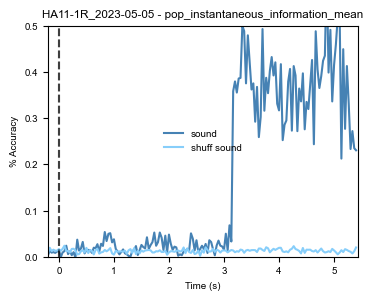

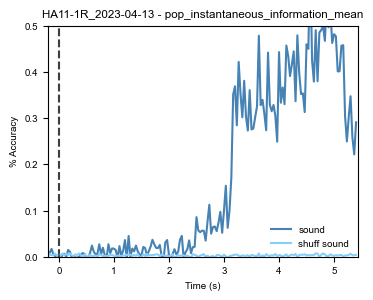

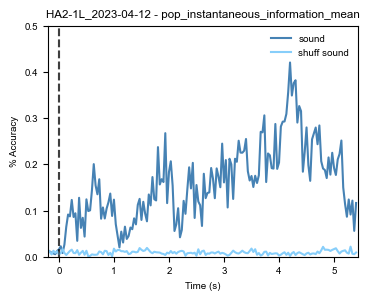

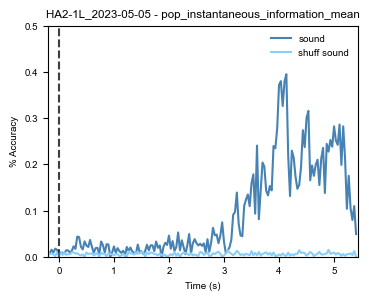

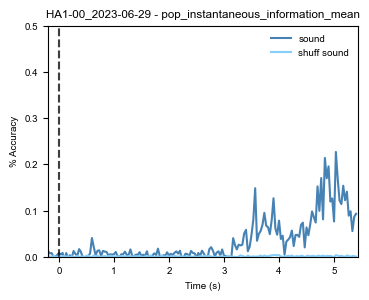

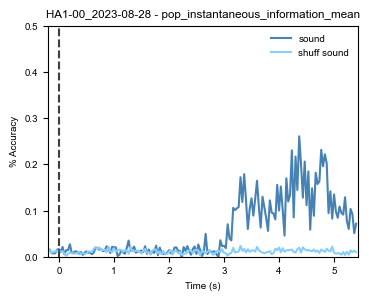

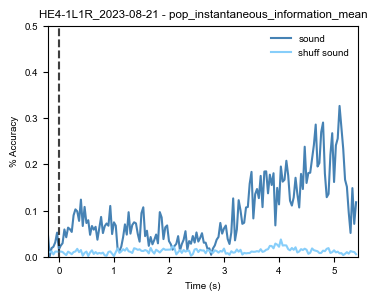

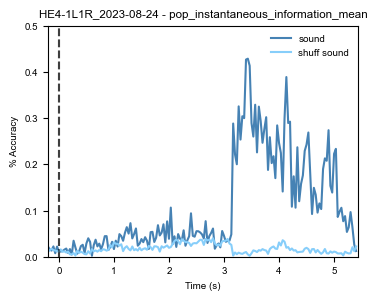

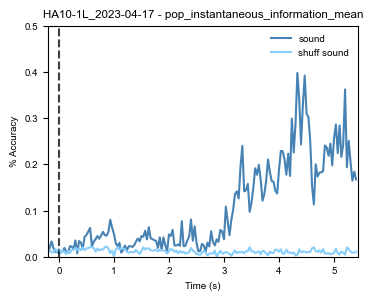

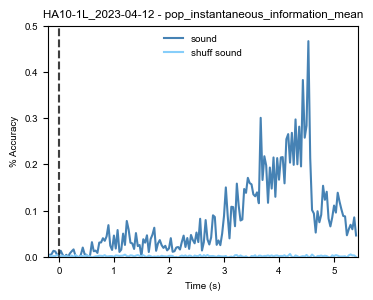

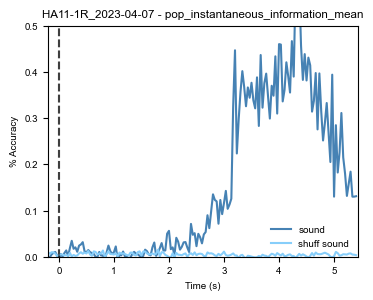

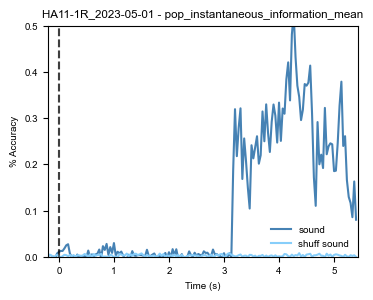

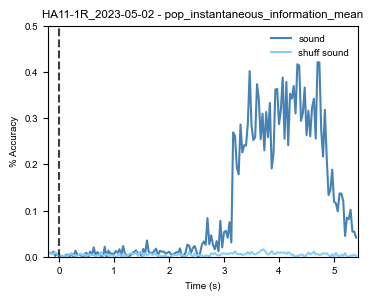

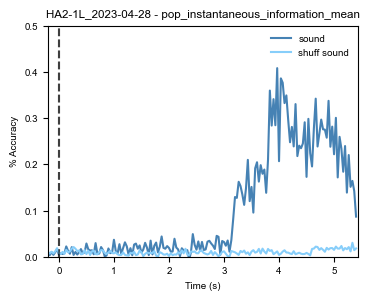

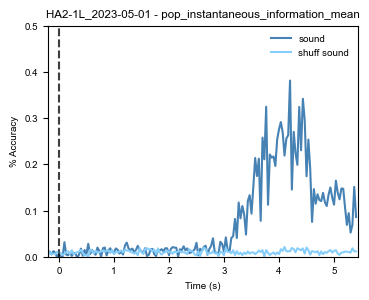

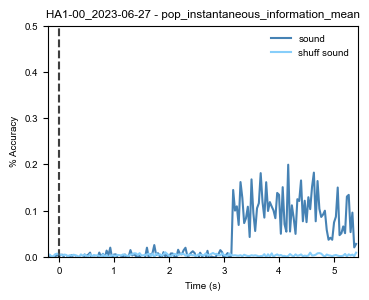

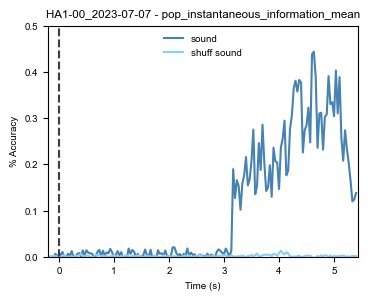

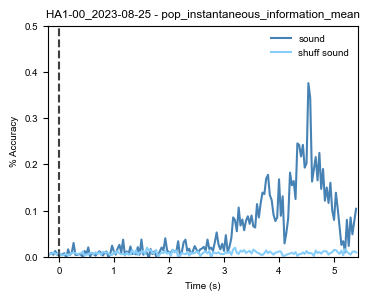

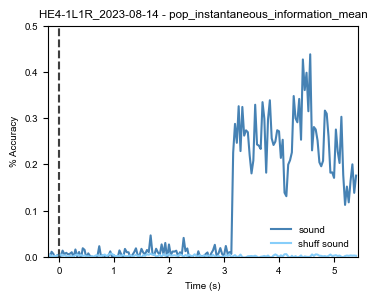

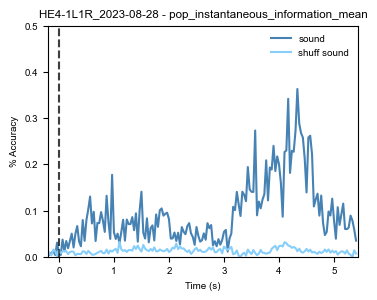

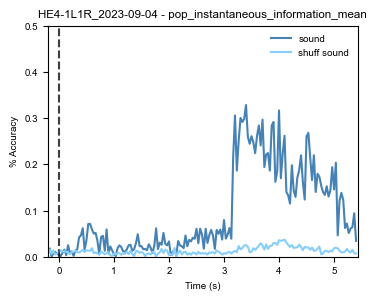

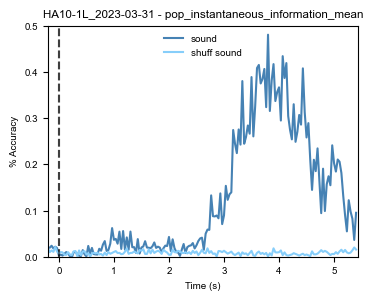

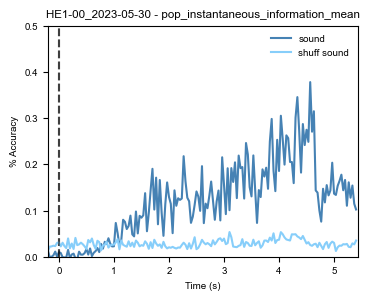

In [ ]:
# Plot individual datasets the selected metric and get concatenated means and SEMs

os.makedirs(f'V:/Connie/results/glm_decoding/{current_decoded_variable}_decoding', exist_ok=True)
for dataset_key in results_pre_all_sb:
  # dataset_key = list(results_pre_all_sb.keys())[0]
  plotter.plot_dataset_metric_with_sem(mean_results_list,dataset_key, decoder_types,  
                            title= None, 
                            metric = f'pop_instantaneous_information_mean',
                            start_frame=0,
                            xlabel='Seconds', 
                            ylabel= ylabel, #'SC Metric 1 Value',
                            ylim = (0.0,.5), #ylimss, #(0.01,.03)
                            xlim = (0,169), #in terms of frames (30 frames = 1 second)
                          save_dir='V:\Connie/results\glm_decoding\sound_decoding', #,#save_dir_contexts,
                          labels = labels,
                          colors = colors_used)       

In [10]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)


Statistical Comparisons:
pv vs pyr:
KS statistic: 0.0523, p-value: 0.4785
Mann-Whitney U statistic: 222097.5000, p-value: 0.5806

pv vs som:
KS statistic: 0.0640, p-value: 0.8596
Mann-Whitney U statistic: 17602.0000, p-value: 0.8854

pyr vs som:
KS statistic: 0.0907, p-value: 0.3289
Mann-Whitney U statistic: 80018.0000, p-value: 0.8106



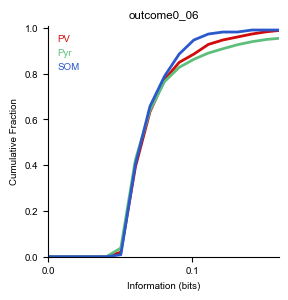

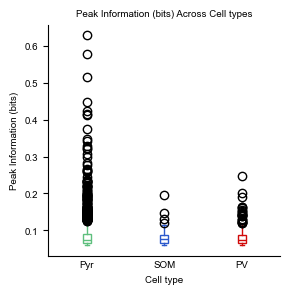

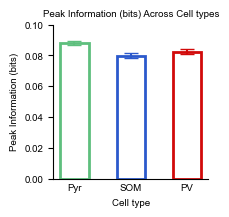

Cell type: pyr, Number of significant neurons: 1423
Cell type: som, Number of significant neurons: 114
Cell type: pv, Number of significant neurons: 306
Cell type: all, Number of significant neurons: 1843


In [11]:
#DECIDE WHETHER OR NOT TO USE END FRAME
## shuffled_threshold = analysis_dec.universal_shuffled_threshold(shuffled_structure, start_frame = 14, end_frame = 100, significance_percentile=95)
# shuffled_threshold = analysis_dec.universal_shuffled_threshold(shuffled_structure, start_frame = 14, end_frame = 100, significance_percentile=5, mode='peak')

current_model_type = 'pre' #'pre' or passive
results_pre_all = results_pre_all_sb #results_to_test #results_pre_all_sb
start_frame = 14 #14 before this there is artifact
end_frame = 169 #100 for sound/photostim
threshold = 0.06 #shuffled_threshold['universal_threshold'] #np.max(list(shuffled_threshold['thresholds'].values())) #shuffled_threshold['universal_threshold'] #0.06 #shuffled_threshold['universal_threshold'] #use threshold OR percentile to decide signficant neurons
method = 'threshold_peak'#'shuffled_timepoint' #'threshold_peak'# 'shuffled_peak', 'threshold_peak', 'range_threshold', 'combined', 'shuffled_timepoint'
metric_to_plot = 'sc_instantaneous_information_mean'
current_decoder_type = 'outcome' #shuffled/
prtile = 90 

# Replace dot with underscore in threshold for directory name
# threshold_str = f"{str(threshold).replace('.', '_')}_{method}"#str(threshold).replace('.', '_')
if method in ['threshold_peak', 'range_threshold']:
    threshold_str = str(threshold).replace('.', '_')
else:
    threshold_str = (f'{prtile} _ {method}')

save_path = f'{plotter.save_results}/{current_model_type}{current_decoder_type}/'
os.makedirs(save_path , exist_ok=True)

# Analyze peaks by cell type
peaks_by_celltype = []
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure, method = method,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = prtile, threshold = threshold, window = 3) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!

cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
if "shuffled" in current_decoder_type:
    current_decoder_type = current_decoder_type.replace('/', '_') #replace / with _
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title=f'{current_decoder_type}{threshold_str}',
                                xlabel = 'Information (bits)',
                                xval=.15,
                                xint=0.1,
                                save_path=None, #f'{save_path}{current_decoder_type}_cdf_thr{threshold_str}.pdf',
                                perform_stats=True)

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    save_path=None #f'{save_path}{current_decoder_type}_box_plot_thr{threshold_str}.pdf'
)

#make boxplot!
plotter.bar_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    ylims = 0.1,
    save_path=None #f'{save_path}{current_decoder_type}_violin_plot_thr{threshold_str}.pdf'
)

#heatmap across datasets
# if "shuffled" in current_decoder_type:
#     current_decoder_type = current_decoder_type.replace('_', '/') #replace / with _
# plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')

# PRINT OUT # OF SIGNIFICANT NEURONS PER CELL TYPE
# Assuming cdf_data is a dictionary with cell types as keys and peaks as values
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')


In [ ]:
#save most informative neurons!
import scipy.io

# Sort peaks by information
sorted_peaks,sorted_peaks_more_info = analysis_dec.sort_peaks_by_information(peaks_by_celltype)
# Prepare the dictionary
matlab_ready = analysis_dec.flatten_for_matlab(sorted_peaks) #needed for SVM decoding

# Save to .mat file
scipy.io.savemat(r'V:/Connie/ProcessedData\sorted_peaks\sorted_peaks_outcome_14to169.mat', matlab_ready)

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from utils.general_stats import GeneralStats as GenStats
GenStats = GenStats()
def plot_significant_neurons_distribution_test(significant_neurons_data, event_frames=None, save_path=None, figure_type='cdf',star_height_percentage=0.05, figsize=(3, 1.6), bin_size=3, gap = (5,5), ylim_axis0 = None): 
        """Plot distribution of significant informative neurons."""
        

        fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=300) #, constrained_layout=True
        plt.subplots_adjust(wspace=0.1,left=0.2, top=2)    # Adjust for more space between plots
        plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})  # Updated font size for clarity

        celltypes = list(['PYR', 'SOM', 'PV'])  # Define cell types to plot
        # Adjusted bin edges and color palette
        bin_edges_bits = np.arange(0.06, .2, .01)

        #save peaks and peak locations for each cell type across all datasets concatenated
        collected_peaks = {celltype: {'peak_values': [], 'peak_frames': []} for celltype in plotter.celltypecolors.keys()}

        # Collect peaks and peak locations for each cell type across datasets   
        for celltype, color in plotter.celltypecolors.items():
            all_peaks = []
            all_peaks_locs = []
            for dataset in significant_neurons_data:
                peaks = significant_neurons_data[dataset][celltype]['peak_values']
                peaks_locs = significant_neurons_data[dataset][celltype]['peak_frames']
                all_peaks.extend(peaks)
                all_peaks_locs.extend(peaks_locs)

            # collect all peaks and peak locations for each cell type
            if not all_peaks:  # Check if there are no peaks for this cell type
                print(f"No significant peaks found for cell type {celltype} in dataset {dataset}. Skipping plot.")
            else:
                #save the peaks and peak locations for each cell type
                collected_peaks [celltype]['peak_values'] = all_peaks
                collected_peaks [celltype]['peak_frames'] = all_peaks_locs
                
            if figure_type == 'violin':
                # Plot violin plot with more customization
                sns.violinplot(
                    x=[celltype] * len(all_peaks),
                    y=all_peaks,
                    ax=axes[0],
                    color=color, #color
                    inner='box',
                    linewidth=.5,
                    edgecolor=color  # Add edge color for better visibility
                    # bw=0.3  # Adjust bandwidth for smoother distributions
                )
                # # Overlay boxplots with controlled width
                # sns.boxplot(x=[celltype] * len(all_peaks),y=all_peaks, color = 'white',fill = False, width=0.2, fliersize=0, linewidth=0.3, ax=axes[0])
                axes[0].set_ylabel("Peak Info. (bits)")
                axes[0].set_xticklabels(celltypes, rotation=45)
                ylims1 =  plt.gca().get_ylim()
                if ylims1[1] < 0.25:  # Check if y-axis limit is greater than 0.25
                    axes[0].set_ylim(0, 0.25)  # Setting y-axis limits to match example
                else:
                    axes[0].set_ylim(0, ylims1[1]+.03)  # Adjust y-axis limit to be slightly above max value
            if figure_type == 'cdf':
                # Calculate CDF
                x1 = np.linspace(0.05, .15, 100)  # Define range of x values
                n1, _ = np.histogram(all_peaks, bins=x1)  # Histogram counts
                p1 = n1 / np.sum(n1)  # Probability
                cdf = np.cumsum(p1)  # Cumulative sum to get CDF
                
                axes[0].plot(x1[:-1], cdf, linewidth= 1, color=color)  # x1[:-1] because histogram bins include right edge
                axes[0].set_ylabel("Cumulative Fraction")
            elif figure_type == 'histogram':
                # Plot histogram
                ## Normalize to percent using density=True and scaling y by 100
                weights = np.ones_like(all_peaks) / len(all_peaks)  # Normalize weights to sum to 1
                axes[0].hist(all_peaks, alpha=1.0, color=color, label=celltype,
                            histtype='step', linewidth=1, density=False,bins = bin_edges_bits,weights=weights)
                axes[0].set_ylabel("Fraction")
            
            # get ylimits
            ylims =  plt.gca().get_ylim()
            # Histogram for peak locations with customized style

            # Calculate CDF
            x1 = np.linspace(1, 169-14, 169-14)  # Define range of x values
            n1, _ = np.histogram(all_peaks_locs, bins=x1)  # Histogram counts
            p1 = n1 / np.sum(n1)  # Probability
            cdf = np.cumsum(p1)  # Cumulative sum to get CDF
            
            # axes[1].plot(x1[:-1], cdf, linewidth= 1, color=color)  # x1[:-1] because histogram bins include right edge
            # axes[1].set_ylabel("cdf")
            axes[1].hist(all_peaks_locs, alpha=0.7, color=color, bins=np.arange(0, 169, bin_size), label=celltype, density=False, weights=np.ones_like(all_peaks_locs) / len(all_peaks_locs), histtype='step', linewidth=1)   
            
        axes[1].set_ylabel("Fraction")
        axes[1].set_xlabel('Peak Info. (bits)')
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)

        #clean up plots
        axes[0].spines['top'].set_visible(False)
        axes[0].spines['right'].set_visible(False)
        # plt.gcf().subplots_adjust(top=0.85)  # Increase space at top for stars
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)

        # Adding labels for event frames if provided
        if event_frames is not None:
            
            xlim = axes[1].get_xlim()
            for frame in event_frames:
                if frame < xlim[1]:
                    axes[1].axvline(x=frame, color='k', linestyle=(0, gap ), alpha=1,lw = 0.7)
            axes[1].set_xticks(event_frames)
            axes[1].set_xticklabels(plotter.event_labels)
            plt.xticks(rotation=45)
        plt.tight_layout()

        # perform permutation test for each cell type
        # Perform pairwise comparisons
        celltype_keys = list(plotter.celltypecolors.keys())
        all_p_values = []
        comparisons = []
        comparisons_names = []
        p_values = []
        test_stats = []
        all_stats_dict = {}

        for i, celltype in enumerate(celltype_keys):
            for j in range(i + 1, len(celltype_keys)):
                other_celltype = celltype_keys[j]
                comparisons.append((i, j))
                # Get data for the two cell types
                data_i = np.array(collected_peaks[celltype]['peak_values'])
                data_j = np.array(collected_peaks[other_celltype]['peak_values'])
                if len(data_i) == 0 or len(data_j) == 0:
                    print(f"No significant peaks found for {celltype} or {other_celltype}. Skipping permutation test.")
                    continue
                
                # Perform permutation test
                p_value, stat = GenStats.perform_permutation_test(data_i, data_j, paired=False, n_permutations=10000)
                all_p_values.append(p_value)

                comparisons_names.append((f"{celltype}_peak_vals", f"{other_celltype}_peak_vals"))
                test_stats.append(stat)
                p_values.append(p_value)

                # Save stats for each group
                label1 = f"{celltype}_peakvals"
                label2 = f"{other_celltype}_peakvals"
                all_stats_dict[label1] =GenStats.get_basic_stats(data_i)
                all_stats_dict[label2] = GenStats.get_basic_stats(data_j)

                print(f"Permutation test p-value for {celltype} vs {other_celltype}: {p_value:.4f}")    

        _, significance_stars = GenStats.calculate_bonferroni_significance(all_p_values, alpha=0.05)

        # Add significance stars to the plot
        max_y = max([max(collected_peaks[ct]['peak_values'] or [0]) for ct in celltype_keys])
        ylims = axes[0].get_ylim()


        # Add significance stars to the plot
        count = 0
        for (i, j), star in zip(comparisons, significance_stars):
            if star != 'ns':  # Only add significance line if there is a star
                star_y = max_y+max_y*.1+count# base_height + (step_height * count) #
                plotter.add_significance_line(axes[0], x1=i, x2=j, y=star_y,significance=star, color='black',star_height_percentage = star_height_percentage, fontsize=7)
                count += max_y*.05

        for i, celltype in enumerate(celltype_keys):
            for j in range(i + 1, len(celltype_keys)):
                other_celltype = celltype_keys[j]
                comparisons.append((i, j))
                # Get data for the two cell types
                data_i = np.array(collected_peaks[celltype]['peak_frames'])
                data_j = np.array(collected_peaks[other_celltype]['peak_frames'])
                if len(data_i) == 0 or len(data_j) == 0:
                    print(f"No significant peaks found for {celltype} or {other_celltype}. Skipping permutation test.")
                    continue
                
                # Perform permutation test
                p_value, stat = GenStats.perform_permutation_test(data_i, data_j, paired=False, n_permutations=10000)
                all_p_values.append(p_value)

                comparisons_names.append((f"{celltype}_peak_locs", f"{other_celltype}_peak_locs"))
                test_stats.append(stat)
                p_values.append(p_value)

                # Save stats for each group
                label1 = f"{celltype}_peaklocs"
                label2 = f"{other_celltype}_peaklocs"
                all_stats_dict[label1] = GenStats.get_basic_stats(data_i)
                all_stats_dict[label2] = GenStats.get_basic_stats(data_j)

                print(f"Permutation test locs p-value for {celltype} vs {other_celltype}: {p_value:.4f}")

        #redo y limits for axes[0]
        if ylim_axis0 is not None:
            axes[0].set_ylim(ylim_axis0)
        else:   
            max_y = max([max(collected_peaks[ct]['peak_values'] or [0]) for ct in celltype_keys])
            axes[0].set_ylim(0, max(0.25, max_y + 0.03))  # Adjust y-axis limit to be slightly above max value
        if bin_size is None:
            bin_size = 3
        # get actual save_path by getting the string in front of the last /
        if save_path and '/' in save_path:
            save_path_updated = save_path[:save_path.rfind('/')]
        if save_path:
            plt.savefig(save_path,  dpi=300) #bbox_inches='tight',
            df_tests = GenStats.to_table(comparisons_names, test_stats, p_values, save_path=f'{save_path_updated}/stat_tests_info_neurons_peaks_bin{bin_size}.csv',type='permutation')
            df_stats = GenStats.basic_stats_to_table(all_stats_dict, save_path=f'{save_path_updated}/basic_stats_info_neurons_peaks_bin{bin_size}.csv')
        else:
            df_tests = GenStats.to_table(comparisons_names, test_stats, all_p_values,type='permutation')
   
        plt.show()


def plot_significant_neuron_percentages_by_celltype_test(significance_struc, neuron_groups, save_path=None, star_height_percentage=0.1):
        """
        Plot the percentage of significantly modulated neurons per dataset for each cell type (% within each cell type).
        
        Parameters:
        -----------
        significance_struc : dict
            Dictionary containing significant neuron data by dataset and cell type.
        neuron_groups : dict
            Dictionary containing all neuron indices for each dataset, organized by cell type.
        save_path : str, optional
            Path to save the plot
        """
        plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})
        percentages_by_celltype = {ct: [] for ct in plotter.celltypecolors.keys()}
        
        # Track totals across all datasets
        total_significant_across_datasets = 0
        total_neurons_across_datasets = 0

        for dataset in significance_struc:
            for celltype in plotter.celltypecolors:
                celltype_neurons = neuron_groups[dataset]['neuron_groups'].get(celltype, np.array([])).flatten()
                total_neurons_celltype = len(celltype_neurons)
                total_neurons_across_datasets += total_neurons_celltype

                if total_neurons_celltype > 0:
                    significant_neurons = significance_struc[dataset][celltype]['neuron_indices']
                    total_significant = len(significant_neurons)
                    total_significant_across_datasets += total_significant
                    percentages_by_celltype[celltype].append((total_significant / total_neurons_celltype) * 100)
                else:
                    percentages_by_celltype[celltype].append(0)

        print(f'Total significant neurons across all datasets: {total_significant_across_datasets}')
        print(f'Total neurons across all datasets: {total_neurons_across_datasets}')

        # Calculate mean and SEM for each cell type
        means = {ct: np.mean(percentages_by_celltype[ct]) for ct in percentages_by_celltype}
        sems = {ct: np.std(percentages_by_celltype[ct]) / np.sqrt(len(percentages_by_celltype[ct])) 
                for ct in percentages_by_celltype}

        # Plot bar chart
        fig, ax = plt.subplots(figsize=(1, 1), dpi=300)
        x_positions = np.arange(len(plotter.celltypecolors))
        colors = [plotter.celltypecolors[ct] for ct in plotter.celltypecolors]

        for i, (ct, color) in enumerate(zip(plotter.celltypecolors, colors)):
            mean = means[ct]
            sem = sems[ct]
            # ax.bar(
            #     x_positions[i],
            #     mean,
            #     facecolor='white',
            #     edgecolor=color,
            #     alpha=1,
            #     width=0.6,
            #     linewidth=1
            # )
            # ax.errorbar(
            #     x_positions[i],
            #     mean,
            #     yerr=sem,
            #     fmt='none',
            #     ecolor=color,
            #     elinewidth=1,
            #     capsize=2,
            #     capthick=1
            # )
            ax.bar(
                x_positions[i],
                mean,
                facecolor=color,
                edgecolor='white',
                alpha=1,
                width=0.6,
                linewidth=0.1
            )
            ax.errorbar(
                x_positions[i],
                mean,
                yerr=sem,
                fmt='none',
                ecolor='black',
                elinewidth=.5,
                capsize=2,
                capthick=.5
            )

        # Aesthetics
        ax.set_xticks(x_positions)
        ax.set_xticklabels([plotter.cell_type_labels[ct] for ct in plotter.celltypecolors])
        plt.xticks(rotation=45)
        ax.set_ylabel("% Informative")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ylims =  plt.gca().get_ylim()

        # perform permutation test for each cell type
        celltype_keys = list(plotter.celltypecolors.keys())
        all_p_values = []
        comparisons = []
        all_stats_dict = {}
        test_stats = []
        comparisons_names = []
        # Loop through each pair of cell types
        for i, celltype in enumerate(celltype_keys):
            for j in range(i + 1, len(celltype_keys)):
                other_celltype = celltype_keys[j]
                comparisons.append((i, j))
                # Get data for the two cell types
                data_i = np.array(percentages_by_celltype[celltype])
                data_j = np.array(percentages_by_celltype[other_celltype])
                if len(data_i) == 0 or len(data_j) == 0:
                    print(f"No significant peaks found for {celltype} or {other_celltype}. Skipping permutation test.")
                    continue
                
                # Perform permutation test
                p_value, stat = GenStats.perform_permutation_test(data_i, data_j, paired=True, n_permutations=10000)
                all_p_values.append(p_value)
                test_stats.append(stat)
                comparisons_names.append((f"{celltype}_%_sig_info", f"{other_celltype}_%_sig_info"))

                print(f"Unpaired permutation test p-value for {celltype} vs {other_celltype}: {p_value:.4f}")   
                # Save stats for each group
                label1 = f"{celltype}_%_sig_info"
                label2 = f"{other_celltype}_%_sig_info"
                all_stats_dict[label1] = GenStats.get_basic_stats(data_i)
                all_stats_dict[label2] = GenStats.get_basic_stats(data_j) 

        _, significance_stars = GenStats.calculate_bonferroni_significance(all_p_values, alpha=0.05)

        # Add significance stars to the plot
        count = 0
        for (i, j), star in zip(comparisons, significance_stars):
            if star != 'ns':  # Only add significance line if there is a star
                add_significance_line_test(ax, x1=i, x2=j, y=ylims[1]+count,significance=star, color='black',star_height_percentage =star_height_percentage)
                count += 10

        # get actual save_path by getting the string in front of the last /
        if save_path and '/' in save_path:
            save_path_updated = save_path[:save_path.rfind('/')]

        if save_path:
            plt.savefig(save_path, bbox_inches="tight")
            df_tests = GenStats.to_table(comparisons_names, test_stats, all_p_values, save_path=f'{save_path_updated}/stat_tests_info_sig_percent.csv',type='permutation paired')
            df_stats = GenStats.basic_stats_to_table(all_stats_dict, save_path=f'{save_path_updated}/basic_stats_info_sig_percent.csv')

        plt.tight_layout()
        plt.show()

        print("Significantly Modulated Neurons (% ± SEM):")
        for ct in plotter.celltypecolors:
            print(f"{ct}: {means[ct]:.2f} ± {sems[ct]:.2f}%")

        return means, sems, percentages_by_celltype

def add_significance_line_test(ax, x1, x2=None, y=None, significance='', color='black', star_height_percentage = 0.01, fontsize=7,lw=.5):
        """
        Add significance line between two bars in the plot.
        If only x1 is provided, draw only the significance star without a line.
        Parameters:
        -----------
        ax : matplotlib.axes.Axes
            The axes to draw on
        x1, x2 : float
            x-coordinates for the line endpoints
        y : float, optional
            y-coordinate for the line. If None, uses 95% of ylim
        significance : str
            The significance marker to display
        color : str
            Color of the line and text
        """

        # Get current y-axis limits
        ylims = ax.get_ylim()
        
        # If y is not provided, set it to 95% of the y-axis range
        if y is None:
            y = ylims[1] * 1.1

        if x2 is not None:  # Draw line if both x1 and x2 are provided
            # Calculate line height as small percentage of y-axis range
            line_height = y * star_height_percentage#(ylims[1] - ylims[0]) * star_height_percentage
            line_y = y 
            text_y = y + line_height
            print(line_y, text_y)

            # Draw the line
            ax.plot([x1, x1, x2, x2], [y, line_y, line_y, y], 
                    lw=lw, color=color)
            
            # Add text
            ax.text((x1 + x2) * 0.5, text_y, significance, 
                    ha='center', va='bottom', color=color, fontsize=fontsize)
        else:  # Only x1 is provided, so draw only the significance star
            if y is not None:
                ax.text(x1, y, significance, 
                    ha='center', va='bottom', color=color, fontsize=fontsize)

C:\Users\runyan1\AppData\Local\Temp\ipykernel_57464\1764132048.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(celltypes, rotation=45)
C:\Users\runyan1\AppData\Local\Temp\ipykernel_57464\1764132048.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(celltypes, rotation=45)
C:\Users\runyan1\AppData\Local\Temp\ipykernel_57464\1764132048.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(celltypes, rotation=45)


Permutation test p-value for pyr vs som: 0.9323
Permutation test p-value for pyr vs pv: 0.0370
Permutation test p-value for som vs pv: 0.0810
Bonferroni corrected alpha threshold: 0.01667
Permutation test locs p-value for pyr vs som: 0.3016
Permutation test locs p-value for pyr vs pv: 0.0608
Permutation test locs p-value for som vs pv: 0.0360


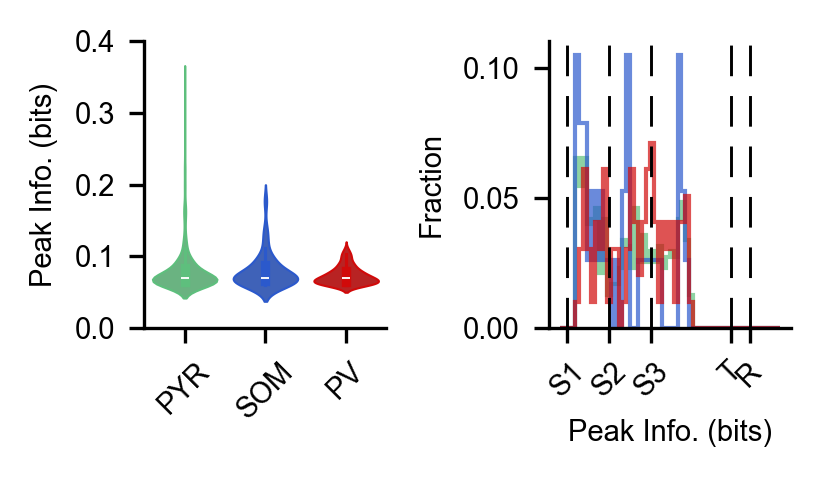

In [35]:
bin_size = 3
plot_significant_neurons_distribution_test(
            significant_neurons_data = significance_struc,
            save_path=f'{save_path}{types}{decoder_type}_{end_frame}cdf_peak_info_bin{bin_size}.pdf',
            event_frames = plotter.event_frames,
            figure_type='violin',
            star_height_percentage = 0.01,
            figsize = (2.8, 1.6),
            bin_size= bin_size,
            gap = (10.5,6.8), #11,6.5,
            ylim_axis0= (0,0.4)
        )
# means, sems, percentages_by_celltype = plot_significant_neuron_percentages_by_celltype_test( significance_struc,analysis_dec.celltype_info, save_path=f'{save_path}bar_{decoder_type}{end_frame}_percent_informative.pdf',star_height_percentage = -0.05)


c:\Code\Github\GLM-analysis\utils\Plotter.py:2574: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(celltypes, rotation=45)
c:\Code\Github\GLM-analysis\utils\Plotter.py:2574: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(celltypes, rotation=45)
c:\Code\Github\GLM-analysis\utils\Plotter.py:2574: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(celltypes, rotation=45)


Permutation test p-value for pyr vs som: 0.9373
Permutation test p-value for pyr vs pv: 0.0342
Permutation test p-value for som vs pv: 0.0770
Bonferroni corrected alpha threshold: 0.01667
Permutation test locs p-value for pyr vs som: 0.2958
Permutation test locs p-value for pyr vs pv: 0.0592
Permutation test locs p-value for som vs pv: 0.0412


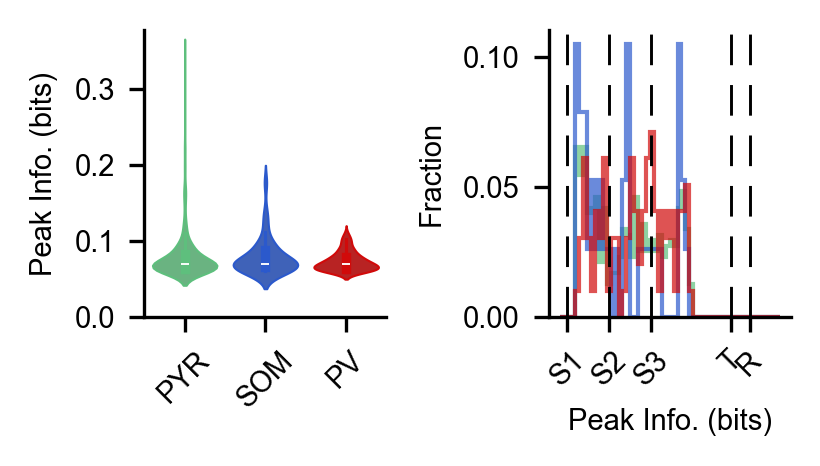

c:\Code\Github\GLM-analysis\utils\Plotter.py:2419: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([ct.upper() for ct in celltypes], rotation=45)
c:\Code\Github\GLM-analysis\utils\Plotter.py:2419: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([ct.upper() for ct in celltypes], rotation=45)
c:\Code\Github\GLM-analysis\utils\Plotter.py:2419: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([ct.upper() for ct in celltypes], rotation=45)


Permutation test p-value for pyr vs som: 0.8639
Permutation test p-value for pyr vs pv: 0.0048
Permutation test p-value for som vs pv: 0.0644
Bonferroni corrected alpha threshold: 0.01667
Permutation test locs p-value for pyr vs som: 0.9727
Permutation test locs p-value for pyr vs pv: 0.0438
Permutation test locs p-value for som vs pv: 0.1704


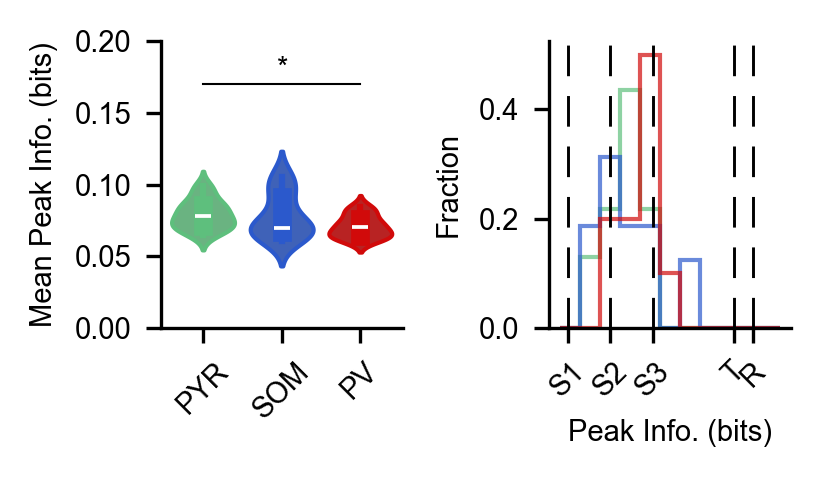

c:\Code\Github\GLM-analysis\utils\Plotter.py:2419: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([ct.upper() for ct in celltypes], rotation=45)
c:\Code\Github\GLM-analysis\utils\Plotter.py:2419: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([ct.upper() for ct in celltypes], rotation=45)
c:\Code\Github\GLM-analysis\utils\Plotter.py:2419: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([ct.upper() for ct in celltypes], rotation=45)


Permutation test p-value for pyr vs som: 0.8577
Permutation test p-value for pyr vs pv: 0.0026
Permutation test p-value for som vs pv: 0.0588
Bonferroni corrected alpha threshold: 0.01667
Permutation test locs p-value for pyr vs som: 0.9805
Permutation test locs p-value for pyr vs pv: 0.0388
Permutation test locs p-value for som vs pv: 0.1666


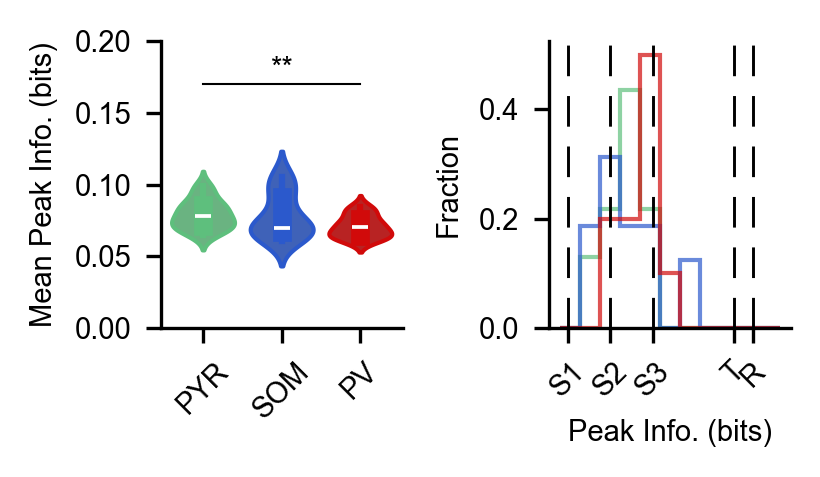

Total significant neurons across all datasets: 610
Total neurons across all datasets: 7263
Unpaired permutation test p-value for pyr vs som: 0.0550
Unpaired permutation test p-value for pyr vs pv: 0.0182
Unpaired permutation test p-value for som vs pv: 0.4892
Bonferroni corrected alpha threshold: 0.01667


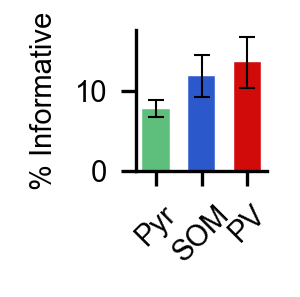

Significantly Modulated Neurons (% ± SEM):
pyr: 7.81 ± 1.06%
som: 11.91 ± 2.61%
pv: 13.66 ± 3.19%
W:\Connie/results\Bassi2025/fig2/glm_decoding//sound_category/


In [ ]:
# Plot significant neurons distribution
types = 'violin'  # 'cdf' or 'histogram' or 'violin'
decoder_type = 'choice'  # 'choice' or 'sound_category' or 'photostim' or 'outcome'

save_path = f'{plotter.save_results}/{decoder_type}/'#f'{plotter.save_results}_14to169/{current_model_type}{decoder_type}/' #f'{plotter.save_results}/{current_model_type}{start_frame}{current_decoder_type}/'
os.makedirs(save_path, exist_ok=True)
end_frame = 100 #169
significant_neurons_data, significance_struc, significant_neurons = analysis_dec.analyze_significant_neurons(
            results_dict=results_pre_all_sb,
            shuffled_structure = shuffled_structure,
            method = 'threshold_peak', #threshold_peak', 'range_threshold'
            decoder_type = decoder_type,  # Or your preferred decoder type
            start_frame = 14,                 # Specify start frame
            end_frame = end_frame,  #100                  # Specify end frame if needed, else None
            metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
            significance_percentile = 95,         #used to determine significant cells
            threshold = 0.06 ,                   #None or 0.06 (from Runyan 2017)

        )

plotter.plot_significant_neurons_distribution(
            significant_neurons_data = significance_struc,
            save_path=f'{save_path}{types}{decoder_type}_{end_frame}sessionmeans_cdf_peak_info.pdf',
            event_frames = plotter.event_frames,
            figure_type=types,
            star_height_percentage = 0.0001,
            figsize = (2.8, 1.6),
            bin_size= 3
        )

plotter.plot_significant_neuron_session_means(
            significant_neurons_data = significance_struc,
            save_path=f'{save_path}{types}{decoder_type}_{end_frame}sessionmeans_cdf_peak_info.pdf',
            event_frames = plotter.event_frames,
            figure_type=types,
            star_height_percentage = 0.0001,
            fig_size = (2.8, 1.6)
        )

plotter.plot_significant_neuron_session_means(
            significant_neurons_data = significance_struc,
            save_path=f'{save_path}{types}{decoder_type}_{end_frame}sessionmeans_cdf_peak_info.pdf',
            event_frames = plotter.event_frames,
            figure_type=types,
            star_height_percentage = 0.0001,
            fig_size = (2.8, 1.6)
        )

means, sems, percentages_by_celltype = plotter.plot_significant_neuron_percentages_by_celltype( significance_struc,analysis_dec.celltype_info, save_path=f'{save_path}bar_{decoder_type}{end_frame}_percent_informative.pdf', star_height_percentage=-0.1)

print(save_path)

Total significant neurons across all datasets: 1896
Total neurons across all datasets: 7263
Unpaired permutation test p-value for pyr vs som: 0.0036
Unpaired permutation test p-value for pyr vs pv: 0.0006
Unpaired permutation test p-value for som vs pv: 0.9831
Bonferroni corrected alpha threshold: 0.01667


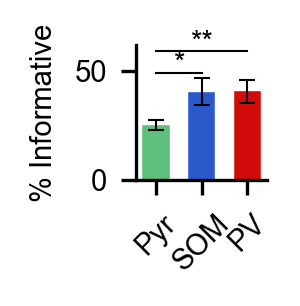

Significantly Modulated Neurons (% ± SEM):
pyr: 25.35 ± 2.20%
som: 40.48 ± 6.28%
pv: 40.61 ± 5.13%


In [43]:
types = 'violin'  # 'cdf' or 'histogram' or 'violin'
decoder_type = 'choice'  # 'choice' or 'sound_category' or 'photostim' or 'outcome'

save_path = f'{plotter.save_results}/{decoder_type}/'#f'{plotter.save_results}_14to169/{current_model_type}{decoder_type}/' #f'{plotter.save_results}/{current_model_type}{start_frame}{current_decoder_type}/'
os.makedirs(save_path, exist_ok=True)
end_frame = 169 #169
significant_neurons_data, significance_struc, significant_neurons = analysis_dec.analyze_significant_neurons(
            results_dict=results_pre_all_sb,
            shuffled_structure = shuffled_structure,
            method = 'threshold_peak', #threshold_peak', 'range_threshold'
            decoder_type = decoder_type,  # Or your preferred decoder type
            start_frame = 14,                 # Specify start frame
            end_frame = end_frame,  #100                  # Specify end frame if needed, else None
            metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
            significance_percentile = 95,         #used to determine significant cells
            threshold = 0.06 ,                   #None or 0.06 (from Runyan 2017)

        )
means, sems, percentages_by_celltype = plotter.plot_significant_neuron_percentages_by_celltype( significance_struc,analysis_dec.celltype_info, save_path=f'{save_path}bar_{decoder_type}{end_frame}_percent_informative.pdf', star_height_percentage=-0.05)


In [28]:
print(percentages_by_celltype)

{'pyr': [6.116207951070336, 5.88235294117647, 9.939759036144578, 4.119850187265917, 6.015037593984962, 13.20754716981132, 16.917293233082706, 22.065727699530516, 7.012987012987012, 2.7777777777777777, 4.477611940298507, 3.3582089552238807, 3.8461538461538463, 4.301075268817205, 5.485232067510549, 4.929577464788732, 5.0, 4.519774011299435, 6.769230769230769, 15.41095890410959, 15.957446808510639, 5.263157894736842, 6.229508196721312], 'som': [6.666666666666667, 0.0, 7.6923076923076925, 0.0, 12.5, 25.0, 42.10526315789473, 42.857142857142854, 17.391304347826086, 14.285714285714285, 14.285714285714285, 5.0, 0.0, 0.0, 0.0, 0.0, 15.384615384615385, 5.88235294117647, 16.666666666666664, 30.0, 0.0, 7.142857142857142, 11.11111111111111], 'pv': [6.976744186046512, 3.225806451612903, 6.25, 2.631578947368421, 10.0, 22.727272727272727, 23.25581395348837, 58.82352941176471, 7.4074074074074066, 0.0, 10.81081081081081, 9.090909090909092, 0.0, 7.5, 0.0, 5.128205128205128, 3.3333333333333335, 35.7142857

6.0


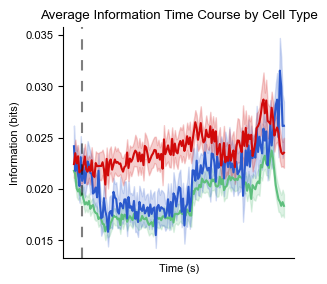

Sig neurons total 1624


KeyboardInterrupt: 

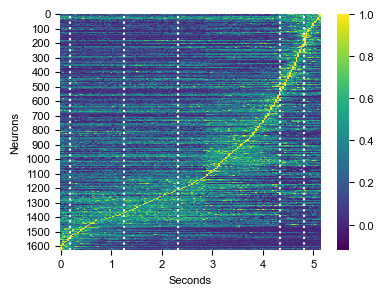

In [36]:
# Call the visualization function
threshold = 0.06
significant_neurons_data, sig_struct, sig_neurons = analysis_dec.wrapper_info_plots_analysis(
    results_dict=results_pre_all_sb,
    shuffled_structure = shuffled_structure,
    method = 'threshold_peak', #threshold_peak', 'range_threshold'
    plotter=plotter,
    decoder_type = 'sound_category',  # Or your preferred decoder type
    start_frame = 14,                 # Specify start frame
    end_frame = 169,  #100                  # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = threshold ,                   #None or 0.06 (from Runyan 2017)
    save_path= None #f'{save_path}{current_decoder_type}_sig_cel_thr{str(threshold)}'
)

# # Save significant neurons data to a .mat file
# mat_file_path = os.path.join(save_path, f'significant_neurons_data_none.mat')
# sp.io.savemat(mat_file_path, significant_neurons_data)


In [13]:
#LOAD ALIGNED DATA! TO MAKE PLOTS
from helper_functions.data_pipeline import DataPipeline
pipeline = DataPipeline()
data_loaders, celltype_info = pipeline.load_data(datasets=datasets, load_celltypes=True)

# Initialize processor with alignment parameters
processor = DatasetProcessor(alignment={
    'type': 'pre',
    'data_type': 'deconv'
})

fields_to_separate = ['condition','left_turn'] # ['left_turn'] #is_stim_trial, correct, condition
# 
# Create trial divider for condition splitting
trial_divider = TrialDivider()

# Process and align all datasets
aligned_data = processor.process_datasets(
    data_loaders=data_loaders,
    celltype_info=celltype_info,
    save_path='aligned_data.pkl'
)

# For each dataset, create condition splits
for (animalID, date), data in aligned_data.items():
    print(f"\nProcessing {animalID} {date}")
    
    # Create condition splits
    
    all_conditions, condition_array = trial_divider.divide_trials_from_df(
        trial_info_df=data['trial_info'],
        good_trials=data['good_trials'],
        fields_to_separate=fields_to_separate
    )
    
    # Store conditions in aligned_data for later use
    aligned_data[(animalID, date)]['all_conditions'] = all_conditions
    print(f"Found {len(all_conditions)} conditions")

# Verify alignment worked
for (animalID, date), data in aligned_data.items():
    print(f"\nDataset: {animalID} {date}")
    print(f"Aligned imaging shape: {data['aligned_imaging'].shape}")
    print(f"Number of good trials: {len(data['good_trials'])}")
    print(f"Number of conditions: {len(data['all_conditions'])}")

Loading data for: Animal: HA11-1R, Date: 2023-05-05, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-04-13, Server: V:
Loading data for: Animal: HA2-1L, Date: 2023-04-12, Server: V:
Loading data for: Animal: HA2-1L, Date: 2023-05-05, Server: V:
Loading data for: Animal: HA1-00, Date: 2023-06-29, Server: V:
Loading data for: Animal: HA1-00, Date: 2023-08-28, Server: W:
Loading data for: Animal: HE4-1L1R, Date: 2023-08-21, Server: W:
Loading data for: Animal: HE4-1L1R, Date: 2023-08-24, Server: W:
Loading data for: Animal: HA10-1L, Date: 2023-04-10, Server: V:
Loading data for: Animal: HA10-1L, Date: 2023-04-17, Server: V:
Loading data for: Animal: HA10-1L, Date: 2023-04-12, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-04-07, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-05-01, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-05-02, Server: V:
Loading data for: Animal: HA2-1L, Date: 2023-04-28, Server: V:
Loading data for: Animal: HA2-1L, Date: 202

In [14]:
current_decoder_type = 'choice'

In [15]:
# Initialize visualization tools
trial_plotter = TrialPlotter()
trial_divider = TrialDivider()
cell_viz = CellVisualizer()

# Create output directories if they don't exist
import os
base_figure_dir = f'{save_results}/figures/{current_decoder_type}'
os.makedirs(f'{base_figure_dir}/heatmaps', exist_ok=True)
os.makedirs(f'{base_figure_dir}/example_cells', exist_ok=True)
print(f"Base figure directory: {base_figure_dir}")

Base figure directory: W:\Connie/results\Bassi2025/fig2/glm_decoding//figures/choice


In [14]:

significant_neurons_data = sorted_peaks 
# Plot for each dataset
for dataset in significant_neurons_data:
    # Extract animal ID and date from dataset name
    animalID, date = dataset.split('_')
    
    # Get the aligned data for this dataset
    data = aligned_data[(animalID, date)]
    
    
    # Plot heatmaps for different cell types
    for cell_type in ['pyr']: #, 'pv', 'som'
        if cell_type in significant_neurons_data[dataset]:
            # Get significant cells for this cell type
            sig_cells = significant_neurons_data[dataset][cell_type]
            
            # Plot example cells for each condition
            for cell_id in sig_cells[:15]:  # Plot first 3 cells of each type (:3)
                # for trials, comb, label in all_conditions:
                # Create valid filename by replacing problematic characters
                # safe_label = label.replace('/', '_').replace(' ', '_')
                print(f"Plotting {cell_type} cell {cell_id} for {animalID} {date}")

NameError: name 'sorted_peaks' is not defined

In [ ]:
# PLOT EXAMPLE CELLS (NOT SORTED BY SIGNIFICANCE) - Plot first 3 cells of each type

example_dataset = ['HA11-1R_2023-05-05']
significant_neurons_data = sorted_peaks 
# Plot for each dataset
for dataset in significant_neurons_data:
    # Extract animal ID and date from dataset name
    animalID, date = dataset.split('_')
    
    # Get the aligned data for this dataset
    data = aligned_data[(animalID, date)]
    
    # Create output directory for this dataset
    dataset_dir = os.path.join('figures', 'informative_cells', dataset)
    os.makedirs(dataset_dir, exist_ok=True)
    
    # Plot heatmaps for different cell types
    for cell_type in ['pyr']: #, 'pv', 'som'
        if cell_type in significant_neurons_data[dataset]:
            # Get significant cells for this cell type
            sig_cells = significant_neurons_data[dataset][cell_type]
            
            # Plot example cells for each condition
            for n,cell_id in enumerate(sig_cells[:15]):  # Plot first 3 cells of each type (:3)
                # for trials, comb, label in all_conditions:
                # Create valid filename by replacing problematic characters
                # safe_label = label.replace('/', '_').replace(' ', '_')
                print(f"Plotting {cell_type} cell {cell_id} for {animalID} {date}")
                
                cell_viz.plot_informative_cell(
                    aligned_imaging=data['aligned_imaging'],
                    cell_id=cell_id,
                    all_conditions=data['all_conditions'], #condition_indices=trials,
                    title_base=f'{animalID} {date} {cell_type} Cell {cell_id} ', #- {label}
                    peak_info = sorted_peaks_more_info[dataset][cell_type]['peak_values'][n], #peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']['peak_values'][cell_id],
                    save_path=f'{base_figure_dir}/example_cells/{animalID}_{date}_{cell_type}_cell_{cell_id}' #_{safe_label}
                )
print("Plotting complete!")

Plotting pyr cell 268 for HA11-1R 2023-05-05
Plotting pyr cell 199 for HA11-1R 2023-05-05
Plotting pyr cell 48 for HA11-1R 2023-05-05
Plotting pyr cell 180 for HA11-1R 2023-05-05
Plotting pyr cell 360 for HA11-1R 2023-05-05
Plotting pyr cell 139 for HA11-1R 2023-05-05
Plotting pyr cell 53 for HA11-1R 2023-05-05
Plotting pyr cell 23 for HA11-1R 2023-05-05
Plotting pyr cell 45 for HA11-1R 2023-05-05
Plotting pyr cell 61 for HA11-1R 2023-05-05
Plotting pyr cell 330 for HA11-1R 2023-05-05
Plotting pyr cell 31 for HA11-1R 2023-05-05
Plotting pyr cell 359 for HA11-1R 2023-05-05
Plotting pyr cell 166 for HA11-1R 2023-05-05
Plotting pyr cell 147 for HA11-1R 2023-05-05
Plotting pyr cell 288 for HA11-1R 2023-04-13
Plotting pyr cell 51 for HA11-1R 2023-04-13
Plotting pyr cell 293 for HA11-1R 2023-04-13
Plotting pyr cell 192 for HA11-1R 2023-04-13
Plotting pyr cell 353 for HA11-1R 2023-04-13
Plotting pyr cell 241 for HA11-1R 2023-04-13


c:\Code\Github\GLM-analysis\utils\cell_visualizer.py:64: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, n_conditions, figsize=(3*n_conditions, 3))


Plotting pyr cell 58 for HA11-1R 2023-04-13
Plotting pyr cell 297 for HA11-1R 2023-04-13
Plotting pyr cell 95 for HA11-1R 2023-04-13
Plotting pyr cell 273 for HA11-1R 2023-04-13
Plotting pyr cell 118 for HA11-1R 2023-04-13
Plotting pyr cell 156 for HA11-1R 2023-04-13
Plotting pyr cell 33 for HA11-1R 2023-04-13
Plotting pyr cell 235 for HA11-1R 2023-04-13
Plotting pyr cell 139 for HA11-1R 2023-04-13
Plotting pyr cell 61 for HA2-1L 2023-05-05
Plotting pyr cell 261 for HA2-1L 2023-05-05
Plotting pyr cell 141 for HA2-1L 2023-05-05
Plotting pyr cell 281 for HA2-1L 2023-05-05
Plotting pyr cell 196 for HA2-1L 2023-05-05
Plotting pyr cell 156 for HA2-1L 2023-05-05
Plotting pyr cell 190 for HA2-1L 2023-05-05
Plotting pyr cell 180 for HA2-1L 2023-05-05
Plotting pyr cell 240 for HA2-1L 2023-05-05
Plotting pyr cell 277 for HA2-1L 2023-05-05
Plotting pyr cell 219 for HA2-1L 2023-05-05
Plotting pyr cell 230 for HA2-1L 2023-05-05
Plotting pyr cell 194 for HA2-1L 2023-05-05
Plotting pyr cell 40 for HA

IndexError: index 68 is out of bounds for axis 0 with size 15

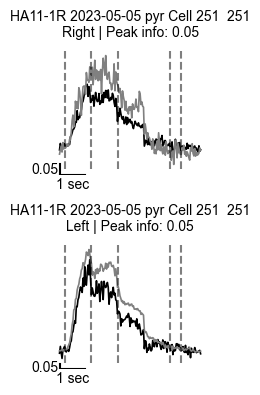

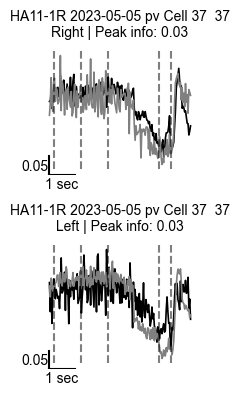

In [ ]:
example_dataset = ['HA11-1R_2023-05-05']
condition_colors = ['black','gray','black','gray'] #['#377eb8', '#e41a1c']  # blue and red

# Plot for each dataset
for dataset in example_dataset:
    # Extract animal ID and date from dataset name
    animalID, date = dataset.split('_')
    
    # Get the aligned data for this dataset
    data = aligned_data[(animalID, date)]
    
    # Create output directory for this dataset
    dataset_dir = os.path.join('figures', 'informative_cells', dataset)
    os.makedirs(dataset_dir, exist_ok=True)
    
    # Plot heatmaps for different cell types
    for cell_type in ['pyr', 'pv', 'som']:
        if cell_type in significant_neurons_data[dataset]:
            # Get significant cells for this cell type
            sig_cells = significant_neurons_data[dataset][cell_type]
            
            # Plot example cells for each condition
            for cell_id in sig_cells[:1]:  # Plot first 3 cells of each type (:3)
                # for trials, comb, label in all_conditions:
                # Create valid filename by replacing problematic characters
                # safe_label = label.replace('/', '_').replace(' ', '_')
                
                cell_viz.plot_informative_cell_overlay_minimal_axis(
                    aligned_imaging=data['aligned_imaging'],
                    cell_id=cell_id,
                    all_conditions=data['all_conditions'], #condition_indices=trials,
                    condition_colors=condition_colors,
                    title_base=f'{animalID} {date} {cell_type} Cell {cell_id} ', #- {label}
                    peak_info = peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']['peak_values'][cell_id],
                    subplot_split='right',
                    orientation='vertical', figsize=(2,4),
                    smoothing=None,
                    shading = False,
                    save_path='' #f'{base_figure_dir}/example_cells/{animalID}_{date}_{cell_type}_cell_{cell_id}' #_{safe_label}
                )

In [ ]:
# def plot_avg_informative_cell_overlay(aligned_imaging: np.ndarray,
#                                   results: dict,  # Additional input for neuron data
#                                   cell_id: int,
#                                   all_conditions: List[tuple],
#                                   condition_colors: List[str],
#                                   decoded_variable: str,  # Decoded variable for neuron data
#                                   title_base: Optional[str] = None,
#                                   peak_info: Optional[float] = None,
#                                   frames: Optional[tuple] = None,
#                                   subplot_split: Optional[str] = None,
#                                   legend: Optional[str] = None,
#                                   figsize: Optional[Tuple[float, float]] = None,  # NEW
#                                   orientation: str = "horizontal",  # NEW: "horizontal" or "vertical"
#                                   smoothing: Optional[float] = None,
#                                   shading: Optional[bool] = False,
#                                   save_path: Optional[str] = None) -> Tuple[plt.Figure, plt.Axes]:

#     event_frames = np.array([6., 38., 70., 131., 145.])
#     event_labels = ['S1', 'S2', 'S3', 'T', 'R']

#     # Set global font size and family 
#     plt.rcParams.update({'font.size': 10, 'font.family': 'arial'})

#     condition_labels = [label for (_, _, label) in all_conditions]
#     group_labels = split_condition_labels(condition_labels, subplot_split)
#     # print(f"Group labels: {group_labels}")

#     n_groups = len(group_labels)
#     if orientation == "vertical":
#         fig, axs = plt.subplots(1+ n_groups,1, figsize=figsize or (10 * n_groups, 12), squeeze=False)  # 2 subplots (traces + info)
#         plt.subplots_adjust(hspace=0.1)
#     else:  # horizontal
#         fig, axs = plt.subplots(1,1+ n_groups, figsize=figsize or (12 * n_groups, 10), squeeze=False)  # 2 subplots (traces + info)
#         plt.subplots_adjust(wspace=0.1)
#     axs = axs.flatten()
 

#     for ax, (group_name, group_condition_labels) in zip(axs[:n_groups], group_labels.items()):
#         # Subplot 1: Traces for all conditions
#         for (trials, _, label), color in zip(all_conditions, condition_colors):
#             if label not in group_condition_labels:
#                 continue

#             cell_data = aligned_imaging[trials, cell_id, :]
#             if frames is not None:
#                 start_frame, end_frame = frames
#                 cell_data = cell_data[:, start_frame:end_frame]
#             else:
#                 start_frame = 0

#             mean_trace = np.mean(cell_data, axis=0)
#             sem_trace = np.std(cell_data, axis=0) / np.sqrt(len(trials))

#             # Optional smoothing
#             if smoothing is not None and smoothing > 0:
#                 mean_trace = gaussian_filter1d(mean_trace, sigma=smoothing)
#                 sem_trace = gaussian_filter1d(sem_trace, sigma=smoothing)

#             ax.plot(mean_trace, color=color, linewidth=.8, label=label)

#             # Uncomment the following line to add SEM shading
#             if shading:
#                 ax.fill_between(np.arange(len(mean_trace)),
#                                 mean_trace - sem_trace,
#                                 mean_trace + sem_trace,
#                                 alpha=0.3,
#                                 color=color)

#         # Add event lines
#         if event_frames is not None:
#             for frame in event_frames:
#                 ax.axvline(x=frame , color='k', linestyle=(0, (2, 2)), alpha=0.5) 
#         ax.set_xticks(event_frames)
#         ax.set_xticklabels([])

#         # clean up appearance
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)

#         # Title
#         # ax.set_title(f"{title_base or 'Cell'} {cell_id}\n{group_name}" +
#         #                 (f" | Peak info: {peak_info:.2f}" if peak_info else ""),
#         #                 fontsize=10)
#         # ax.set_title((f"Info: {peak_info:.2f}" if peak_info else ""), fontsize=10)
#         ax.set_ylabel("Act.\n(a.u.)", fontsize=10)

#         #make sure  y-limits are the same for all subplots
#         if len(axs) > 1:  
#             all_y = np.concatenate([ax.get_lines()[0].get_ydata() for ax in axs[:n_groups] if ax.get_lines()])
#             y_min, y_max = np.min(all_y), np.max(all_y)
#             y_range = y_max - y_min
#             for ax in axs[:n_groups]:
#                 ax.set_ylim(y_min - .1 * y_range, y_max + 0.1 * y_range)
        

#     # Subplot 2: Information in bits (for the selected neuron)
#     ax_info = axs[n_groups]  # Now this is a specific subplot

#     # Extracting the data for the neuron using the given information
#     neuron_data = results[decoded_variable]['sc_instantaneous_information_mean'][:, cell_id]

#     ax_info.plot(neuron_data, color='k', linewidth=.8)  # Single trace for the neuron data
#     #find peak value and plot yline at that value
#     _info_peak_value = np.max(neuron_data)
#     ax_info.axhline(y=_info_peak_value, color='m', linestyle='--', label=f'Peak Info: {_info_peak_value:.2f} bits')
#     # ax_info.set_xlabel("Time (s)", fontsize=10)
#     ax_info.set_ylabel("Info\n(bits)", fontsize=10)

#     # # Add event lines
#     # for frame, event_label in zip(event_frames, event_labels):
#     #     if frames is not None and not (start_frame <= frame < end_frame):
#     #         continue
#     #     ax_info.axvline(x=frame - start_frame, color='k', linestyle='--', alpha=0.5)

#     # Add event lines
#     if event_frames is not None:
#         for frame in event_frames:
#             ax_info.axvline(x=frame , color='k', linestyle=(0, (2, 2)), alpha=0.5) 
#     ax_info.set_xticks(event_frames)
#     ax_info.set_xticklabels(event_labels)
#     plt.xticks(rotation=45)   

#     # Removing the ticks for the second subplot
#     # ax_info.tick_params(left=False, labelleft=False)
#     ax_info.spines['top'].set_visible(False)
#     ax_info.spines['right'].set_visible(False)

#     plt.tight_layout()

#     if save_path:
#         plt.savefig(save_path, bbox_inches='tight', dpi=300)

#     return fig, axs


In [ ]:
# def find_special_neurons(dataset, sig_neurons, mod_values, peaks_by_celltype,
#                          mod_threshold=0.1, info_threshold=0.06):
#     """Find neurons in different categories based on modulation and information."""

#     special_neurons = {
#         'most_modulated': {'neuron_id': None, 'mod_val': 0, 'info_val': 0, 'cell_type': None},
#         'most_informative': {'neuron_id': None, 'mod_val': 0, 'info_val': 0, 'cell_type': None},
#         'mod_not_info': {'neuron_id': None, 'mod_val': 0, 'info_val': 0, 'cell_type': None},
#         'info_not_mod': {'neuron_id': None, 'mod_val': 0, 'info_val': 0, 'cell_type': None}
#     }

#     # Build info dictionary
#     info_dict = {}
#     for cell_type in ['pyr', 'pv', 'som']:
#         if cell_type in peaks_by_celltype.get(dataset, {}):
#             sc_data = peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']
#             global_indices = sc_data['global_indices']
#             peak_values = sc_data['peak_values']
#             for idx, neuron_id in enumerate(global_indices):
#                 info_dict[neuron_id] = {'info': peak_values[idx], 'cell_type': cell_type}

#     # Handle sig_neurons
#     if sig_neurons is None:
#         sig_neurons = np.array(list(info_dict.keys())) if info_dict else np.array([])
#     else:
#         sig_neurons = np.array(sig_neurons)

#     # Handle modulation values
#     if mod_values is not None and len(mod_values) == len(sig_neurons):
#         all_mod_values = np.abs(mod_values)
#         has_modulation = True
#     else:
#         all_mod_values = np.zeros(len(sig_neurons))
#         has_modulation = False

#     # Most modulated neuron
#     if has_modulation and len(all_mod_values) > 0:
#         max_mod_idx = np.argmax(all_mod_values)
#         max_mod_neuron = sig_neurons[max_mod_idx]
#         special_neurons['most_modulated'].update({
#             'neuron_id': max_mod_neuron,
#             'mod_val': all_mod_values[max_mod_idx],
#             'info_val': info_dict.get(max_mod_neuron, {'info': 0})['info'],
#             'cell_type': info_dict.get(max_mod_neuron, {'cell_type': 'unknown'})['cell_type']
#         })

#     # Most informative neuron
#     max_info = 0
#     max_info_neuron = None
#     max_info_cell_type = None
#     for neuron_id, info in info_dict.items():
#         if info['info'] > max_info:
#             max_info = info['info']
#             max_info_neuron = neuron_id
#             max_info_cell_type = info['cell_type']

#     if max_info_neuron is not None:
#         mod_val = 0
#         if has_modulation and max_info_neuron in sig_neurons:
#             mod_idx = np.where(sig_neurons == max_info_neuron)[0]
#             if len(mod_idx) > 0:
#                 mod_val = all_mod_values[mod_idx[0]]
#         special_neurons['most_informative'].update({
#             'neuron_id': max_info_neuron,
#             'mod_val': mod_val,
#             'info_val': max_info,
#             'cell_type': max_info_cell_type
#         })

#     # Modulated but not informative
#     if has_modulation:
    #     for idx, neuron_id in enumerate(sig_neurons):
    #         mod_val = all_mod_values[idx]
    #         info_val = info_dict.get(neuron_id, {'info': 0})['info']
    #         if mod_val > mod_threshold and info_val < info_threshold:
    #             if mod_val > special_neurons['mod_not_info']['mod_val']:
    #                 special_neurons['mod_not_info'].update({
    #                     'neuron_id': neuron_id,
    #                     'mod_val': mod_val,
    #                     'info_val': info_val,
    #                     'cell_type': info_dict.get(neuron_id, {'cell_type': 'unknown'})['cell_type']
    #                 })

    # # Informative but not modulated
    # for neuron_id, info in info_dict.items():
    #     if sig_neurons.size == 0 or neuron_id not in sig_neurons:
    #         continue
    #     mod_val = 0
    #     if has_modulation:
    #         mod_idx = np.where(sig_neurons == neuron_id)[0]
    #         if len(mod_idx) > 0:
    #             mod_val = all_mod_values[mod_idx[0]]
    #     if info['info'] > info_threshold and mod_val < mod_threshold:
    #         if info['info'] > special_neurons['info_not_mod']['info_val']:
    #             special_neurons['info_not_mod'].update({
    #                 'neuron_id': neuron_id,
    #                 'mod_val': mod_val,
    #                 'info_val': info['info'],
    #                 'cell_type': info['cell_type']
    #             })

    # return special_neurons

Peaks by cell type: dict_keys(['HA11-1R_2023-05-05', 'HA11-1R_2023-04-13', 'HA2-1L_2023-04-12', 'HA2-1L_2023-05-05', 'HA1-00_2023-06-29', 'HA1-00_2023-08-28', 'HE4-1L1R_2023-08-21', 'HE4-1L1R_2023-08-24', 'HA10-1L_2023-04-17', 'HA10-1L_2023-04-12', 'HA11-1R_2023-04-07', 'HA11-1R_2023-05-01', 'HA11-1R_2023-05-02', 'HA2-1L_2023-04-28', 'HA2-1L_2023-05-01', 'HA1-00_2023-06-27', 'HA1-00_2023-07-07', 'HA1-00_2023-08-25', 'HE4-1L1R_2023-08-14', 'HE4-1L1R_2023-08-28', 'HE4-1L1R_2023-09-04', 'HA10-1L_2023-03-31', 'HE1-00_2023-05-30'])


c:\Code\Github\GLM-analysis\utils\cell_visualizer.py:380: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(2, 1, figsize=figsize or (12, 10), squeeze=False)  # 1 for combined traces + 1 for info


Special neurons plotting complete!


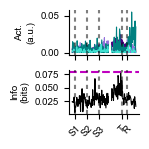

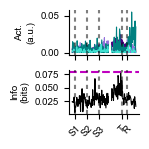

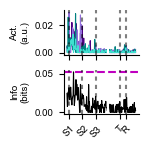

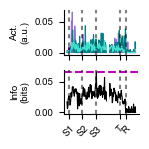

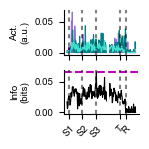

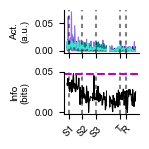

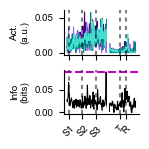

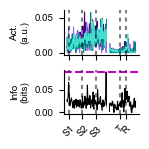

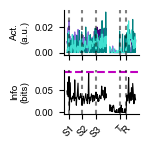

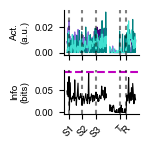

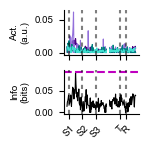

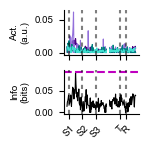

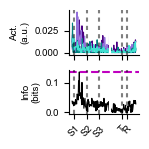

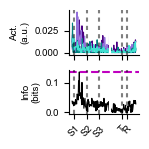

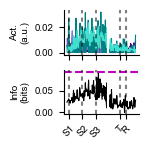

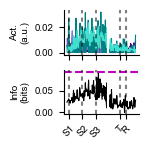

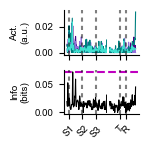

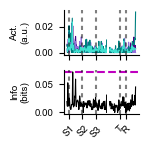

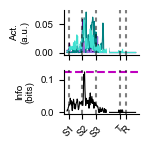

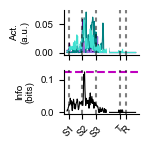

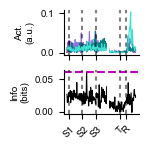

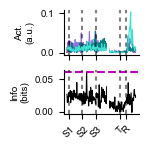

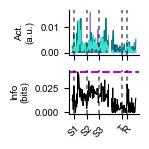

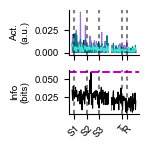

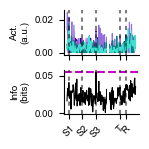

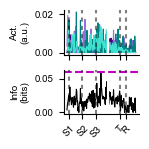

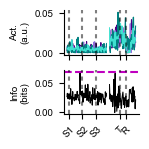

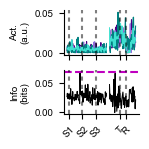

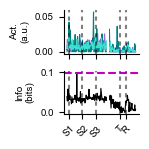

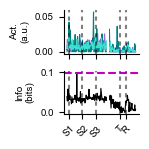

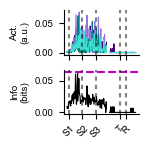

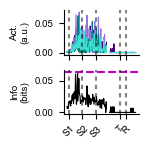

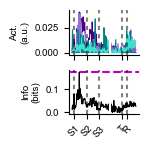

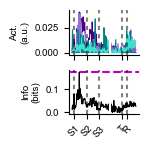

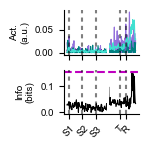

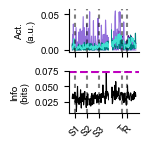

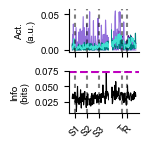

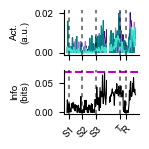

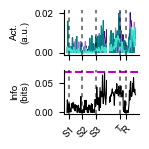

In [20]:
# Plot special neurons for each dataset
to_decode = 'sound_category'
base_figure_dir = f'W:\Connie/results\Bassi2025/fig2\glm_decoding\{to_decode}' #f'V:\Connie/results\glm_decoding/2025/figures/all_balanced\{to_decode}'
os.makedirs(base_figure_dir+'/example_cells', exist_ok=True)
condition_colors = ['indigo','mediumpurple','teal','turquoise']#['black','gray','black','gray'] #['navy','royalBlue','darkred','firebrick'] #['#377eb8', '#e41a1c']  # blue and red

#get the peaks by celltype
current_model_type = 'pre' #'pre' or passive
results_pre_all = results_pre_all_sb #results_to_test #results_pre_all_sb
start_frame = 14 #14 before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold = 0.06 #shuffled_threshold['universal_threshold'] #np.max(list(shuffled_threshold['thresholds'].values())) #shuffled_threshold['universal_threshold'] #0.06 #shuffled_threshold['universal_threshold'] #use threshold OR percentile to decide signficant neurons
method = 'threshold_peak' #'threshold_peak'# 'shuffled_peak', 'threshold_peak', 'range_threshold', 'combined'
metric_to_plot = 'sc_instantaneous_information_mean'
current_decoder_type = to_decode #shuffled/

# Analyze peaks by cell type
peaks_by_celltype = []
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure, method = method,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = prtile, threshold = threshold, window = 3) #, end_frame = 100

print(f"Peaks by cell type: {peaks_by_celltype.keys()}")
for dataset in peaks_by_celltype.keys(): #sig_neurons: #specified_datasets:
    # Extract animal ID and date from dataset name
    animalID, date = dataset.split('_')
    data = aligned_data[(animalID, date)]
    
    # Get significant neurons and their modulation values
    sig_neurons = None #significant_neurons_mod[dataset][0]
    mod_values = None #mod_index_neurons[dataset]
    
    # Find special neurons
    special_neurons = analysis_dec.find_special_neurons(dataset, None, None, peaks_by_celltype, cell_type_filter='som')

    
    for i, (category, info) in enumerate(special_neurons.items()):
        if info['neuron_id'] is not None:
            cur_celltype= info['cell_type']
            cur_cel_id = info['neuron_id']

            cell_viz.plot_avg_informative_cell_overlay(
                    results=results_pre_all_sb[dataset],
                    decoded_variable=to_decode,
                    aligned_imaging=data['aligned_imaging'],
                    cell_id=info['neuron_id'],
                    all_conditions=data['all_conditions'], #condition_indices=trials,
                    condition_colors=condition_colors,
                    title_base=f'{animalID} {date} {cur_celltype} Cell {cur_cel_id}', #- {label}
                    peak_info = info['info_val'], #peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']['peak_values'][cell_id],
                    subplot_split='Right',
                    orientation='vertical', figsize=(1.5,1.5),
                    smoothing=None,
                    shading = False,
                    save_path=f'{base_figure_dir}/example_cells/updated_info_deconv_{animalID}_{date}_{cur_celltype}_cell_{cur_cel_id}.pdf', #_{safe_label},
                    plot_information = True,  # NEW: whether to plot peak info line
                    combine_groups = True,  # NEW: whether to combine groups in one plot
                )
            
            #this plots original plots separated by conditions
            # cell_viz.plot_informative_cell(
            #     aligned_imaging=data['aligned_imaging'],
            #     cell_id=info['neuron_id'],
            #     all_conditions=data['all_conditions'],
            #     title_base=f'{category}\nMI: {info["mod_val"]:.3f}, Info: {info["info_val"]:.3f}\n{info["cell_type"]} Cell {cur_cel_id }',
            # )
            
    
    # plt.tight_layout()
    # plt.savefig(f'{base_figure_dir}/{animalID}_{date}_special_neurons.pdf', 
    #             bbox_inches='tight', dpi=300)
    # plt.close()

    

print("Special neurons plotting complete!")

In [ ]:
#LOAD SIGNIFICANTLY MODULATED CELLS (FROM MATLAB)
import scipy

opto = 0
opto_dir = 'V:/Connie/results/opto_2024/context/mod' #'V:/Connie/results/passive/mod' #'V:/Connie/results/opto_2024/context/mod' #'V:/Connie/results/active/mod' #


# Load the condition_array_trials structure
mat_data = scipy.io.loadmat(os.path.join(opto_dir,'info.mat'))
info = mat_data['info'][0][0]

# Assuming your mouse_date structure is loaded as a numpy array
mouse_dates = [
    item[0].replace('\\', '_').replace('/', '_')  # Replace slashes with underscores for consistency
    for item in info['mouse_date'][0]
]
print(mouse_dates)


current_context = 0
if current_context == 2:
    mod_idx_contexts = scipy.io.loadmat('V:\Connie/results\opto_sound_2025\context\mod\prepost\separate\mod_indexm.mat')
else:
    mod_idx_contexts = scipy.io.loadmat('V:\Connie/results\opto_sound_2025\context\mod\ctrl\separate\mod_indexm.mat')
mod_index_contexts = mod_idx_contexts['mod_indexm']

sig_cels = scipy.io.loadmat('V:\Connie/results\opto_sound_2025\context\mod\prepost\opto_sig_cells.mat') #SOUND OPTO CELLS scipy.io.loadmat('V:\Connie/results\opto_sound_2025\context\sounds\mod\prepost_sound\separate\sound_sig_cells.mat')
sig_cells = sig_cels['opto_sig_cells']-1 #minus one bc of MATLAB indexing


# Create an empty dictionary to store the significant neurons for each mouse_date
significant_neurons_mod = {}
mod_index_neurons = {}
mod_index_neurons_all = {}



# Iterate over the mouse_dates and map to corresponding neurons in sig_cells by index
for idx, mouse_date in enumerate(mouse_dates):
    if idx < len(sig_cells):
        # Get the significant neurons for the current index
        significant_neurons_al = sig_cells[idx][0]
        print(f"Mouse date: {mouse_date}, Significant neurons: {significant_neurons_al}")   
        # Store the results in a dictionary with mouse_date as the key
        significant_neurons_mod[mouse_date] = significant_neurons_al
        current_mod = mod_index_contexts[idx,current_context][0] #mod_index[idx][0][0] #[dataset,context][0]
        # print(f"Mouse date: {mouse_date}, Modulation index: {current_mod}")
        mod_index_neurons[mouse_date] = current_mod[significant_neurons_al]
        mod_index_neurons_all[mouse_date] = current_mod
    else:
        print(f"No significant neurons found for {mouse_date}")

# Now you have a dictionary mapping each dataset to its significant neurons

print(f'total significant neurons: {len(sig_cells)}')

['HA11-1R_2023-05-05', 'HA11-1R_2023-04-13', 'HA2-1L_2023-04-12', 'HA2-1L_2023-05-05', 'HA1-00_2023-06-29', 'HA1-00_2023-08-28', 'HE4-1L1R_2023-08-21', 'HE4-1L1R_2023-08-24', 'HA10-1L_2023-04-10', 'HA10-1L_2023-04-17', 'HA10-1L_2023-04-12', 'HA11-1R_2023-04-07', 'HA11-1R_2023-05-01', 'HA11-1R_2023-05-02', 'HA2-1L_2023-04-28', 'HA2-1L_2023-05-01', 'HA1-00_2023-06-27', 'HA1-00_2023-07-07', 'HA1-00_2023-08-25', 'HE4-1L1R_2023-08-14', 'HE4-1L1R_2023-08-28', 'HE4-1L1R_2023-09-04', 'HE4-1L1R_2023-09-11', 'HA10-1L_2023-03-31', 'HE1-00_2023-05-30']
Mouse date: HA11-1R_2023-05-05, Significant neurons: [[ 64 114 170 186 256  77]]
Mouse date: HA11-1R_2023-04-13, Significant neurons: [[ 17  38  47 156 191 217 260 371  11]]
Mouse date: HA2-1L_2023-04-12, Significant neurons: [[ 34  81  90  98 101 118 128 131 141 143 145 178 181 183 209 255 257 302
  305 312 315 337 339 341 355 363]]
Mouse date: HA2-1L_2023-05-05, Significant neurons: [[ 14  21  23  40  70  72  78 103 108 126 155 166 179 253 256 290

Percentage of significant neurons above threshold 0.06: 25.21%


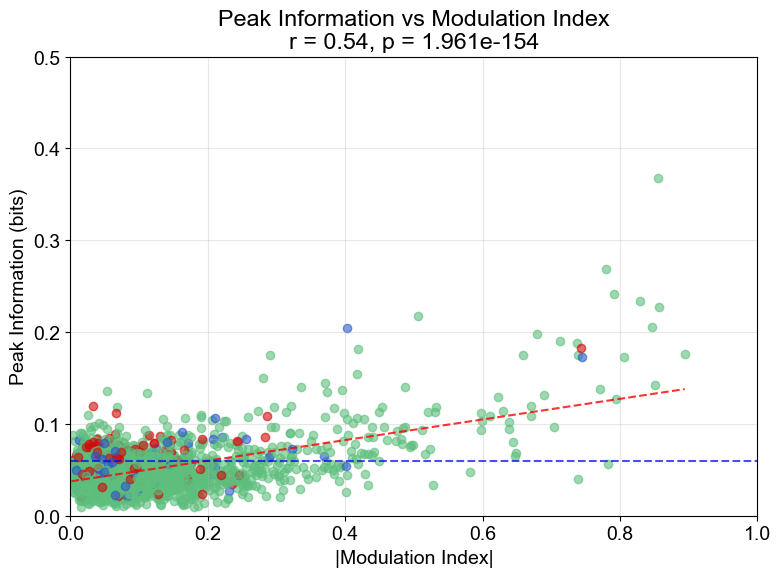

In [ ]:
#PLOT MODULATION INDEX VS PEAK INFORMATION


# Create figure for scatter plot
plt.figure(figsize=(8, 6))

# Store all values for correlation analysis
all_peaks = []
all_mods = []


#recalculate peaks by cell type for this context
if current_context == 0:
    results_pre_all =results_pre_all_sb
    shuffled_to_use = shuffled_structure
else:
    results_pre_all = results_pass_all_sb 
    shuffled_to_use = shuffled_structure_pass

start_frame = 14 #14 before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold =  0.06 #use threshold OR percentile to decide signficant neurons
method = 'threshold_peak'# 'shuffled_peak', 'threshold_peak', 'range_threshold', 'combined'
metric_to_plot = 'sc_instantaneous_information_mean'
current_decoder_type = 'sound_category' #shuffled/
prtile = 90 

# Analyze peaks by cell type
peaks_by_celltype = []
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all, shuffled_to_use, method = method,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = prtile, threshold = threshold, window = 3)

# Get list of datasets except the last one
specified_datasets = list(peaks_by_celltype.keys())#list(significant_neurons_mod.keys())[:-1]

# Iterate through each dataset
for dataset in specified_datasets:
    # Get significant neurons for this dataset
    sig_neurons = significant_neurons_mod[dataset]
    mod_values = np.abs(mod_index_neurons[dataset])
    
    # For each cell type, find matching neurons and their peak values
    for cell_type in ['pyr', 'pv', 'som']:
        if cell_type in peaks_by_celltype[dataset]:
            # Get global indices and peak values for this cell type
            global_indices = peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']['global_indices']
            peak_values = peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']['peak_values']
            
            # Find which significant neurons belong to this cell type
            matching_neurons = np.isin(global_indices, sig_neurons)
            # print(f' {cell_type} {matching_neurons}')
            
            if np.any(matching_neurons):
                # Get the corresponding mod indices
                mod_idx = np.isin(sig_neurons, global_indices)
                # print(f'{cell_type} {mod_idx}')
                
                # Plot scatter for matched neurons
                plt.scatter(mod_values[mod_idx], 
                          peak_values[matching_neurons],
                          alpha=0.6,
                          color=plotter.celltypecolors[cell_type],
                          label=f'{dataset}_{cell_type}')
                
                # Store matched values for correlation
                all_peaks.extend(peak_values[matching_neurons])
                all_mods.extend(mod_values[mod_idx])

# Calculate correlation and add trend line
all_peaks = np.array(all_peaks)
all_mods = np.array(all_mods)

correlation = np.corrcoef(all_mods, all_peaks)[0,1]
pvalue = scipy.stats.pearsonr(all_mods, all_peaks)[1]

# Rest of plotting code remains the same

# Calculate correlation and add trend line
all_peaks = np.array(all_peaks)
all_mods = np.array(all_mods)

# Calculate correlation and p-value
correlation = np.corrcoef(all_mods, all_peaks)[0,1]
pvalue = scipy.stats.pearsonr(all_mods, all_peaks)[1]

# Fit and plot trend line
z = np.polyfit(all_mods, all_peaks, 1)
p = np.poly1d(z)
x_range = np.linspace(min(all_mods), max(all_mods), 100)
plt.plot(x_range, p(x_range), "r--", alpha=0.8)
# Define horizontal_line as the range of x-values

plt.axhline(y=0.06, color='blue', linestyle='--', alpha=0.7, label='Threshold = 0.06')
# Customize plot
plt.xlabel('|Modulation Index|')
plt.ylabel('Peak Information (bits)')
plt.title(f'Peak Information vs Modulation Index\nr = {correlation:.2f}, p = {pvalue:.3e}')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#set plot limits
plt.xlim(0, 1)
plt.ylim(0, 0.5)

#print percentage of significant neurons above threshold
# Calculate the percentage of significant neurons above the threshold
threshold = 0.06
percentage_above_threshold = np.sum(all_peaks > threshold) / len(all_peaks) * 100
print(f"Percentage of significant neurons above threshold {threshold}: {percentage_above_threshold:.2f}%")

# # Save figure
# plt.savefig(os.path.join(base_figure_dir, 'peak_info_vs_mod_index.pdf'), 
#             bbox_inches='tight', 
#             dpi=300)
# plt.close()

In [ ]:
# Initialize visualization tools
trial_plotter = TrialPlotter()
trial_divider = TrialDivider()
cell_viz = CellVisualizer()

# Create output directories if they don't exist
base_figure_dir = f'{save_results}/figures/{current_decoder_type}/most_modulated/passive_context'
os.makedirs(base_figure_dir, exist_ok=True)


# Plot for each dataset
for dataset in specified_datasets:
        
    # Extract animal ID and date from dataset name
    animalID, date = dataset.split('_')
    
    # Get the aligned data for this dataset
    data = aligned_data[(animalID, date)]
    
    # Get significant neurons and their modulation values
    sig_neurons = significant_neurons_mod[dataset][0]
    print(f"Dataset: {dataset}, Significant neurons: {sig_neurons}")
    mod_values = np.abs(mod_index_neurons[dataset])
    
    # Find the most modulated among significant neurons
    max_mod_idx = np.argmax(mod_values)
    max_mod_neuron = sig_neurons[max_mod_idx]
    max_mod_value = mod_values[0][max_mod_idx]

    # Find peak information for this neuron
    peak_info = None
    for cell_type in ['pyr', 'pv', 'som']:
        if cell_type in peaks_by_celltype[dataset]:
            global_indices = peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']['global_indices']
            if max_mod_neuron in global_indices:
                idx = np.where(global_indices == max_mod_neuron)[0][0]
                peak_info = peaks_by_celltype[dataset][cell_type]['sc']['sc_instantaneous_information_mean']['peak_values'][idx]
                cell_type_found = cell_type
                break
    
    print(f"\nDataset: {dataset}")
    print(f"Most modulated neuron: {max_mod_neuron} ({cell_type_found})")
    print(f"Modulation index: {max_mod_value:.3f}")
    print(f"Peak information: {peak_info:.3f}")
    
    # Plot the most modulated neuron
    cell_viz.plot_informative_cell(
        aligned_imaging=data['aligned_imaging'],
        cell_id=max_mod_neuron,
        all_conditions=data['all_conditions'],
        title_base=f'{animalID} {date} {cell_type_found} Cell {max_mod_neuron}\nMod Index: {max_mod_value:.3f}, Peak Info: {peak_info:.3f} bits',
        save_path=f'{base_figure_dir}/{animalID}_{date}_most_modulated_cell_{max_mod_neuron}'
    )

print("Plotting complete!")

NameError: name 'specified_datasets' is not defined